In [1]:


import os
import urllib.request
import pandas as pd

# Create folders
os.makedirs("/content/data/diabetes", exist_ok=True)
os.makedirs("/content/data/cardio", exist_ok=True)


# ============================================================
# 1. PIMA INDIANS DIABETES DATASET
# ============================================================

diabetes_url = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/"
    "pima-indians-diabetes.data.csv"
)

diabetes_file = "/content/data/diabetes/diabetes.csv"

print("Downloading Diabetes dataset...")

urllib.request.urlretrieve(
    diabetes_url,
    diabetes_file
)

diabetes_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df_diabetes = pd.read_csv(
    diabetes_file,
    header=None,
    names=diabetes_columns
)

df_diabetes.to_csv(
    diabetes_file,
    index=False
)

print("✓ Diabetes downloaded")
print("Path:", diabetes_file)
print("Shape:", df_diabetes.shape)


# ============================================================
# 2. UCI CLEVELAND HEART DISEASE DATASET
# ============================================================

heart_url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/heart-disease/"
    "processed.cleveland.data"
)

heart_file = "/content/data/cardio/heartDisease_uci.csv"

print("\nDownloading UCI Heart Disease dataset...")

heart_columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

heart_raw = "/content/data/cardio/processed.cleveland.data"

urllib.request.urlretrieve(
    heart_url,
    heart_raw
)

df_heart = pd.read_csv(
    heart_raw,
    header=None,
    names=heart_columns,
    na_values="?"
)

# Convert target:
# 0 = No heart disease
# 1 = Heart disease
df_heart["target"] = (
    df_heart["target"] > 0
).astype(int)

df_heart.to_csv(
    heart_file,
    index=False
)

print("✓ Heart Disease downloaded")
print("Path:", heart_file)
print("Shape:", df_heart.shape)


# ============================================================
# 3. VERIFY
# ============================================================

print("\n" + "=" * 60)
print("DATASETS READY")
print("=" * 60)

print("\nDiabetes:")
print(df_diabetes.shape)
display(df_diabetes.head())

print("\nHeart Disease:")
print(df_heart.shape)
display(df_heart.head())

print("\nFiles:")
print(diabetes_file)
print(heart_file)

✓ Diabetes downloaded
Path: /content/data/diabetes/diabetes.csv
Shape: (768, 9)

✓ Heart Disease downloaded
Path: /content/data/cardio/heartDisease_uci.csv
Shape: (303, 14)

DATASETS READY

Diabetes:
(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Heart Disease:
(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Files:
/content/data/diabetes/diabetes.csv
/content/data/cardio/heartDisease_uci.csv


In [2]:
import pandas as pd
import numpy as np

# ---- Load ----
diabetes_df = pd.read_csv("data/diabetes/diabetes.csv")
cardio_df = pd.read_csv("/content/data/cardio/heartDisease_uci.csv")

# ---- Clean Diabetes Data ----
# Zero values in these columns are actually missing data
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_as_missing:
    diabetes_df[col] = diabetes_df[col].replace(0, np.nan)
    diabetes_df[col] = diabetes_df[col].fillna(diabetes_df[col].median())

print("Diabetes shape:", diabetes_df.shape)
print(diabetes_df.isnull().sum())

# ---- Clean Cardio Data ----
cardio_df = cardio_df.dropna()
print("Cardio shape:", cardio_df.shape)
print(cardio_df.head())

Diabetes shape: (768, 9)
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Cardio shape: (297, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [12]:
# from sklearn.model_selection import train_test_split
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
# import joblib
# import os

# # Create models folder
# os.makedirs("models", exist_ok=True)


# def train_and_evaluate(df, target_col, model_name):

#     print(f"\nTraining {model_name}...")

#     # Check target column
#     if target_col not in df.columns:
#         print("Available columns:")
#         print(df.columns.tolist())
#         raise ValueError(
#             f"Target column '{target_col}' not found in dataframe."
#         )

#     # Separate features and target
#     X = df.drop(columns=[target_col])
#     y = df[target_col]

#     # Train/test split
#     X_train, X_test, y_train, y_test = train_test_split(
#         X,
#         y,
#         test_size=0.2,
#         random_state=42,
#         stratify=y
#     )

#     # XGBoost model
#     model = XGBClassifier(
#         n_estimators=200,
#         max_depth=4,
#         learning_rate=0.05,
#         eval_metric="logloss",
#         random_state=42
#     )

#     # Train
#     model.fit(X_train, y_train)

#     # Predictions
#     preds = model.predict(X_test)
#     probs = model.predict_proba(X_test)[:, 1]

#     # Metrics
#     accuracy = accuracy_score(y_test, preds)
#     roc_auc = roc_auc_score(y_test, probs)
#     f1 = f1_score(y_test, preds)

#     print(f"\n--- {model_name} ---")
#     print(f"Accuracy: {accuracy:.4f}")
#     print(f"ROC-AUC : {roc_auc:.4f}")
#     print(f"F1-score: {f1:.4f}")

#     # Save model
#     model_path = f"models/{model_name}.pkl"
#     joblib.dump(model, model_path)

#     print(f"Model saved: {model_path}")

#     # Return model + feature names
#     return model, X_train.columns.tolist()


# # ============================================================
# # DIABETES MODEL
# # ============================================================

# diabetes_model, diabetes_features = train_and_evaluate(
#     diabetes_df,
#     "Outcome",
#     "diabetes_model"
# )


# # ============================================================
# # HEART DISEASE MODEL
# # ============================================================

# cardio_model, cardio_features = train_and_evaluate(
#     cardio_df,
#     "target",             # IMPORTANT: not "condition"
#     "cardio_model"
# )


# # ============================================================
# # SAVE FEATURE LISTS
# # ============================================================

# joblib.dump(
#     diabetes_features,
#     "models/diabetes_features.pkl"
# )

# joblib.dump(
#     cardio_features,
#     "models/cardio_features.pkl"
# )

# print("\n" + "=" * 60)
# print("TRAINING COMPLETED SUCCESSFULLY")
# print("=" * 60)

# print("\nDiabetes features:")
# print(diabetes_features)

# print("\nHeart disease features:")
# print(cardio_features)

# print("\nSaved files:")
# print("models/diabetes_model.pkl")
# print("models/cardio_model.pkl")
# print("models/diabetes_features.pkl")
# print("models/cardio_features.pkl")

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import joblib
import os

# Create models folder
os.makedirs("models", exist_ok=True)


def train_and_evaluate(df, target_col, model_name):

    print(f"\n{'=' * 70}")
    print(f"Training {model_name}")
    print(f"{'=' * 70}")

    # Check target column
    if target_col not in df.columns:
        print("Available columns:")
        print(df.columns.tolist())
        raise ValueError(
            f"Target column '{target_col}' not found in dataframe."
        )

    # Separate features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # ============================================================
    # XGBOOST MODEL
    # ============================================================

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        eval_metric="logloss",
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predictions
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    # ============================================================
    # METRICS
    # ============================================================

    accuracy = accuracy_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)
    f1 = f1_score(y_test, preds)

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)

    print(f"\n--- {model_name} - XGBoost ---")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    # ============================================================
    # RANDOM FOREST MODEL
    # ============================================================

    print(f"\nTraining {model_name} - Random Forest...")

    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    )

    # Train Random Forest
    rf_model.fit(X_train, y_train)

    # Predictions
    rf_preds = rf_model.predict(X_test)
    rf_probs = rf_model.predict_proba(X_test)[:, 1]

    # Metrics
    rf_accuracy = accuracy_score(y_test, rf_preds)
    rf_roc_auc = roc_auc_score(y_test, rf_probs)
    rf_f1 = f1_score(y_test, rf_preds)

    # Confusion Matrix
    rf_cm = confusion_matrix(y_test, rf_preds)

    print(f"\n--- {model_name} - Random Forest ---")
    print(f"Accuracy : {rf_accuracy:.4f}")
    print(f"ROC-AUC  : {rf_roc_auc:.4f}")
    print(f"F1-score : {rf_f1:.4f}")

    print("\nConfusion Matrix:")
    print(rf_cm)

    print("\nClassification Report:")
    print(classification_report(y_test, rf_preds))

    # ============================================================
    # SAVE MODELS
    # ============================================================

    xgb_path = f"models/{model_name}_xgboost.pkl"
    rf_path = f"models/{model_name}_random_forest.pkl"

    joblib.dump(model, xgb_path)
    joblib.dump(rf_model, rf_path)

    print(f"\nXGBoost model saved: {xgb_path}")
    print(f"Random Forest model saved: {rf_path}")

    # Return models + feature names
    return (
        model,
        rf_model,
        X_train.columns.tolist()
    )


# ============================================================
# DIABETES MODEL
# ============================================================

diabetes_model, diabetes_rf_model, diabetes_features = train_and_evaluate(
    diabetes_df,
    "Outcome",
    "diabetes_model"
)


# ============================================================
# HEART DISEASE MODEL
# ============================================================

cardio_model, cardio_rf_model, cardio_features = train_and_evaluate(
    cardio_df,
    "target",
    "cardio_model"
)


# ============================================================
# SAVE FEATURE LISTS
# ============================================================

joblib.dump(
    diabetes_features,
    "models/diabetes_features.pkl"
)

joblib.dump(
    cardio_features,
    "models/cardio_features.pkl"
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("TRAINING COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nDiabetes features:")
print(diabetes_features)

print("\nHeart disease features:")
print(cardio_features)

print("\nSaved files:")
print("models/diabetes_model_xgboost.pkl")
print("models/diabetes_model_random_forest.pkl")
print("models/cardio_model_xgboost.pkl")
print("models/cardio_model_random_forest.pkl")
print("models/diabetes_features.pkl")
print("models/cardio_features.pkl")


Training diabetes_model

--- diabetes_model - XGBoost ---
Accuracy : 0.7597
ROC-AUC  : 0.8270
F1-score : 0.6408

Confusion Matrix:
[[84 16]
 [21 33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154


Training diabetes_model - Random Forest...

--- diabetes_model - Random Forest ---
Accuracy : 0.7597
ROC-AUC  : 0.8257
F1-score : 0.6726

Confusion Matrix:
[[79 21]
 [16 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       100
           1       0.64      0.70      0.67        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77   


DIABETES MODEL COMPARISON

Performance Comparison:
----------------------------------------------------------------------
Metric               XGBoost         Random Forest  
----------------------------------------------------------------------
Accuracy             0.7597          0.7597
ROC-AUC              0.8270          0.8257
F1-Score             0.6408          0.6726

----------------------------------------------------------------------
Best Overall Model: Random Forest
----------------------------------------------------------------------


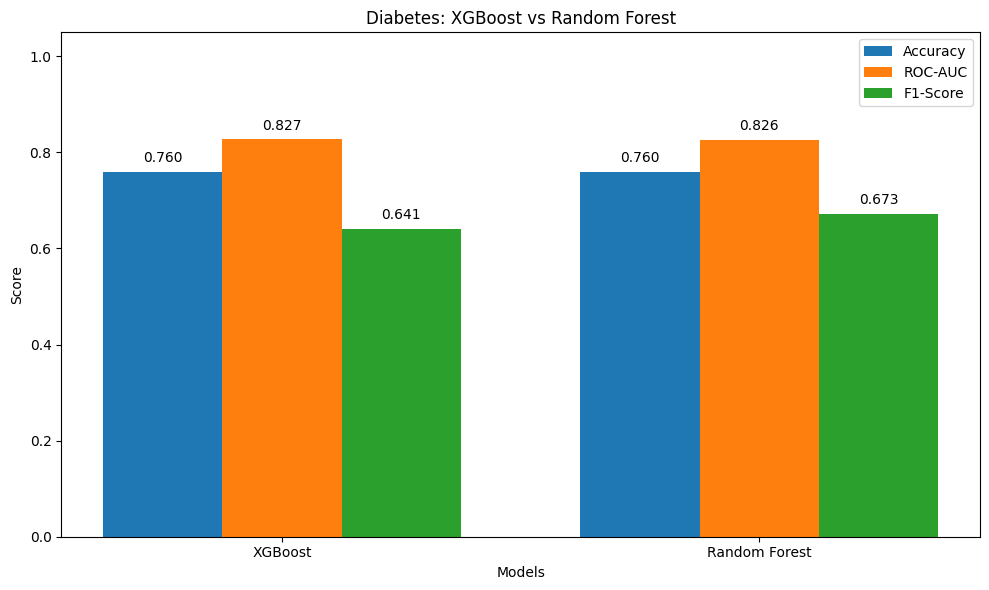

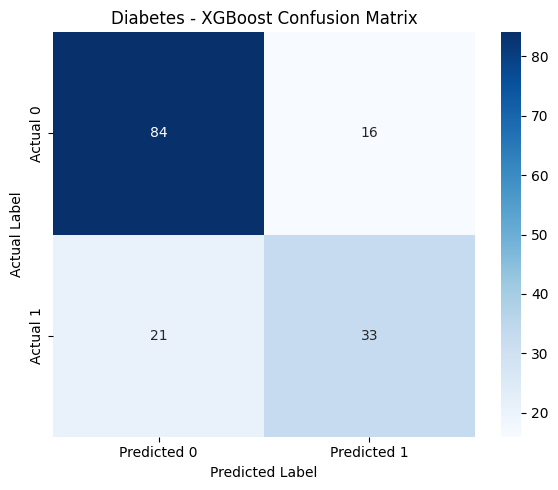

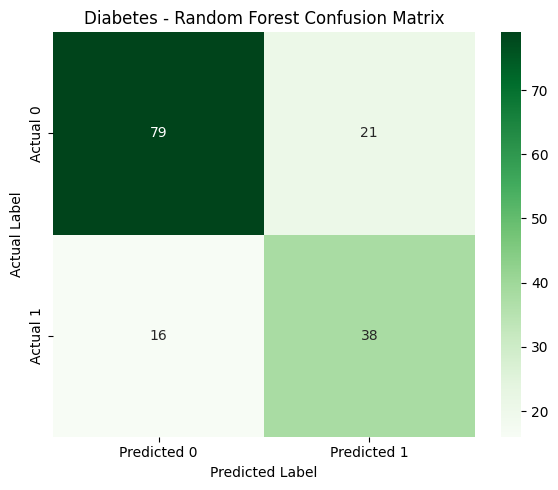


HEART DISEASE MODEL COMPARISON

Performance Comparison:
----------------------------------------------------------------------
Metric               XGBoost         Random Forest  
----------------------------------------------------------------------
Accuracy             0.8333          0.8667
ROC-AUC              0.9051          0.9408
F1-Score             0.8077          0.8519

----------------------------------------------------------------------
Best Overall Model: Random Forest
----------------------------------------------------------------------


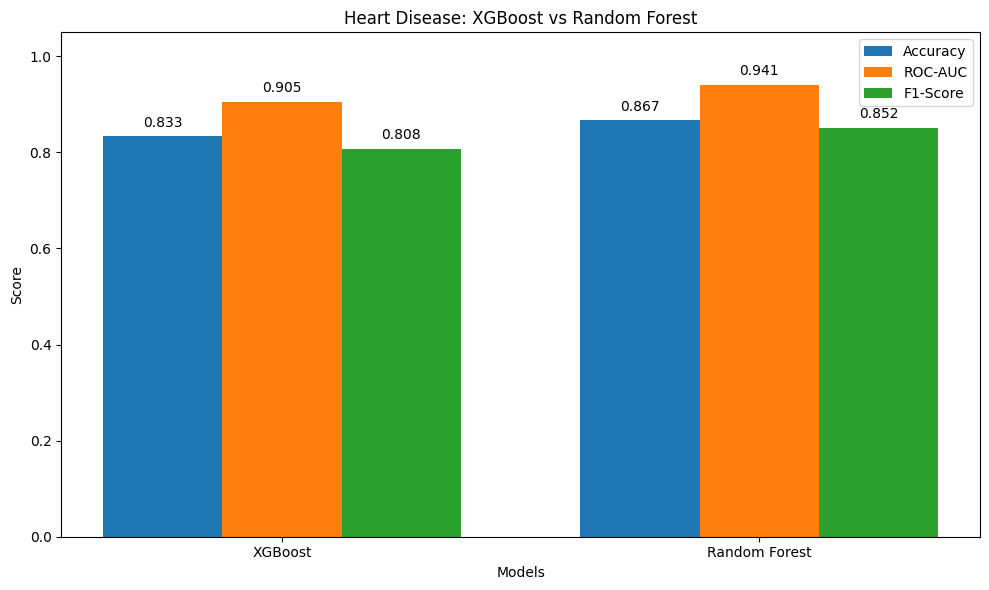

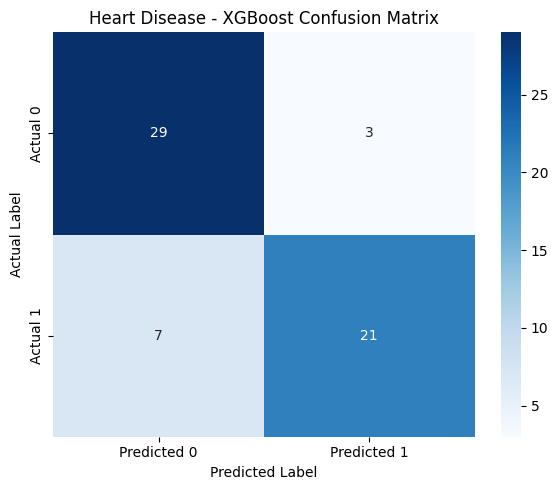

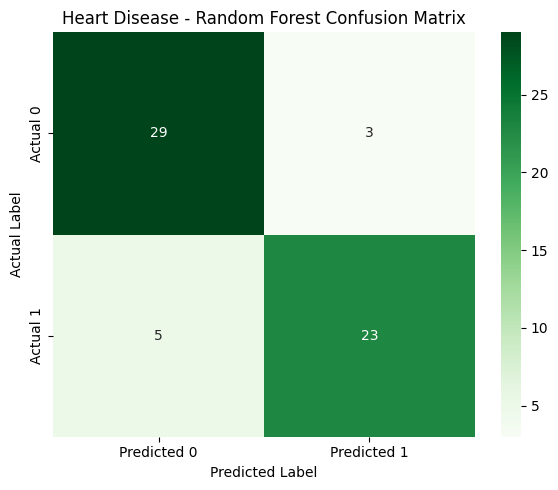

In [6]:
# ============================================================
# MODEL COMPARISON + VISUALIZATION
# XGBOOST vs RANDOM FOREST
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    confusion_matrix
)


def compare_models(df, target_col, dataset_name):

    print("\n" + "=" * 70)
    print(f"{dataset_name.upper()} MODEL COMPARISON")
    print("=" * 70)

    # --------------------------------------------------------
    # Separate features and target
    # --------------------------------------------------------

    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Same split as training
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # --------------------------------------------------------
    # Load saved models
    # --------------------------------------------------------

    xgb_model = joblib.load(
        f"models/{'diabetes_model' if target_col == 'Outcome' else 'cardio_model'}_xgboost.pkl"
    )

    rf_model = joblib.load(
        f"models/{'diabetes_model' if target_col == 'Outcome' else 'cardio_model'}_random_forest.pkl"
    )

    # ========================================================
    # XGBOOST PREDICTIONS
    # ========================================================

    xgb_preds = xgb_model.predict(X_test)
    xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

    xgb_accuracy = accuracy_score(y_test, xgb_preds)
    xgb_auc = roc_auc_score(y_test, xgb_probs)
    xgb_f1 = f1_score(y_test, xgb_preds)

    xgb_cm = confusion_matrix(y_test, xgb_preds)

    # ========================================================
    # RANDOM FOREST PREDICTIONS
    # ========================================================

    rf_preds = rf_model.predict(X_test)
    rf_probs = rf_model.predict_proba(X_test)[:, 1]

    rf_accuracy = accuracy_score(y_test, rf_preds)
    rf_auc = roc_auc_score(y_test, rf_probs)
    rf_f1 = f1_score(y_test, rf_preds)

    rf_cm = confusion_matrix(y_test, rf_preds)

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print("\nPerformance Comparison:")
    print("-" * 70)

    print(f"{'Metric':<20} {'XGBoost':<15} {'Random Forest':<15}")
    print("-" * 70)

    print(
        f"{'Accuracy':<20} "
        f"{xgb_accuracy:.4f}{'':<9} "
        f"{rf_accuracy:.4f}"
    )

    print(
        f"{'ROC-AUC':<20} "
        f"{xgb_auc:.4f}{'':<9} "
        f"{rf_auc:.4f}"
    )

    print(
        f"{'F1-Score':<20} "
        f"{xgb_f1:.4f}{'':<9} "
        f"{rf_f1:.4f}"
    )

    # ========================================================
    # FIND BEST MODEL
    # ========================================================

    scores = {
        "XGBoost": (xgb_accuracy + xgb_auc + xgb_f1) / 3,
        "Random Forest": (rf_accuracy + rf_auc + rf_f1) / 3
    }

    best_model = max(scores, key=scores.get)

    print("\n" + "-" * 70)
    print(f"Best Overall Model: {best_model}")
    print("-" * 70)

    # ========================================================
    # 1. PERFORMANCE COMPARISON BAR CHART
    # ========================================================

    models = ["XGBoost", "Random Forest"]

    accuracy_scores = [
        xgb_accuracy,
        rf_accuracy
    ]

    auc_scores = [
        xgb_auc,
        rf_auc
    ]

    f1_scores = [
        xgb_f1,
        rf_f1
    ]

    x = range(len(models))
    width = 0.25

    plt.figure(figsize=(10, 6))

    plt.bar(
        [i - width for i in x],
        accuracy_scores,
        width=width,
        label="Accuracy"
    )

    plt.bar(
        x,
        auc_scores,
        width=width,
        label="ROC-AUC"
    )

    plt.bar(
        [i + width for i in x],
        f1_scores,
        width=width,
        label="F1-Score"
    )

    plt.xticks(list(x), models)

    plt.ylabel("Score")
    plt.xlabel("Models")
    plt.title(f"{dataset_name}: XGBoost vs Random Forest")

    plt.ylim(0, 1.05)
    plt.legend()

    # Add values on bars
    for i, value in enumerate(accuracy_scores):
        plt.text(
            i - width,
            value + 0.02,
            f"{value:.3f}",
            ha="center"
        )

    for i, value in enumerate(auc_scores):
        plt.text(
            i,
            value + 0.02,
            f"{value:.3f}",
            ha="center"
        )

    for i, value in enumerate(f1_scores):
        plt.text(
            i + width,
            value + 0.02,
            f"{value:.3f}",
            ha="center"
        )

    plt.tight_layout()
    plt.show()

    # ========================================================
    # 2. XGBOOST CONFUSION MATRIX
    # ========================================================

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        xgb_cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )

    plt.title(f"{dataset_name} - XGBoost Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # 3. RANDOM FOREST CONFUSION MATRIX
    # ========================================================

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        rf_cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )

    plt.title(f"{dataset_name} - Random Forest Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return {
        "XGBoost": {
            "Accuracy": xgb_accuracy,
            "ROC-AUC": xgb_auc,
            "F1-Score": xgb_f1,
            "Confusion Matrix": xgb_cm
        },

        "Random Forest": {
            "Accuracy": rf_accuracy,
            "ROC-AUC": rf_auc,
            "F1-Score": rf_f1,
            "Confusion Matrix": rf_cm
        }
    }


# ============================================================
# DIABETES COMPARISON
# ============================================================

diabetes_results = compare_models(
    diabetes_df,
    "Outcome",
    "Diabetes"
)


# ============================================================
# HEART DISEASE COMPARISON
# ============================================================

cardio_results = compare_models(
    cardio_df,
    "target",
    "Heart Disease"
)

In [7]:
import shap

def explain_prediction(model, feature_names, input_row):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(input_row)

    # Handle both single-array and list output formats
    values = shap_values[0] if isinstance(shap_values, list) else shap_values[0]

    contributions = sorted(
        zip(feature_names, values), key=lambda x: abs(x[1]), reverse=True
    )
    top_factors = [{"feature": f, "impact": round(float(v), 3)} for f, v in contributions[:5]]
    return top_factors

# Example usage:
# sample = X_test.iloc[[0]]
# explain_prediction(diabetes_model, diabetes_features, sample)

In [8]:
!apt-get install -y tesseract-ocr -q
!pip install pytesseract pillow -q

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (5.3.4-1build5).
0 upgraded, 0 newly installed, 0 to remove and 11 not upgraded.


In [9]:
import pytesseract
from PIL import Image
import re

def extract_report_values(image_path):
    text = pytesseract.image_to_string(Image.open(image_path))

    patterns = {
        "Glucose": r"glucose[:\s]+(\d+\.?\d*)",
        "BloodPressure": r"(?:blood pressure|bp)[:\s]+(\d+)",
        "Cholesterol": r"cholesterol[:\s]+(\d+\.?\d*)",
        "BMI": r"bmi[:\s]+(\d+\.?\d*)",
    }

    extracted = {}
    text_lower = text.lower()
    for key, pattern in patterns.items():
        match = re.search(pattern, text_lower)
        if match:
            extracted[key] = float(match.group(1))

    return extracted, text

In [10]:
SYMPTOM_KEYWORDS = {
    "frequent urination": {"Glucose": +15},
    "excessive thirst": {"Glucose": +10},
    "fatigue": {"Glucose": +5, "BMI": +2},
    "blurred vision": {"Glucose": +10},
    "chest pain": {"trestbps": +10, "thalach": -5},
    "shortness of breath": {"thalach": -10},
    "dizziness": {"trestbps": +5},
    "high blood pressure": {"trestbps": +15},
}

def parse_symptoms(text):
    text = text.lower()
    detected = {}
    for symptom, adjustments in SYMPTOM_KEYWORDS.items():
        if symptom in text:
            for feature, delta in adjustments.items():
                detected[feature] = detected.get(feature, 0) + delta
    return detected

In [11]:
def fuse_features(base_features: dict, symptom_adjustments: dict, ocr_values: dict):
    """
    base_features: manual form input (dict of all required model features)
    symptom_adjustments: output of parse_symptoms()
    ocr_values: output of extract_report_values()
    """
    final = dict(base_features)

    # OCR values override manual input if present
    for k, v in ocr_values.items():
        if k in final:
            final[k] = v

    # Symptom adjustments nudge the values slightly
    for k, delta in symptom_adjustments.items():
        if k in final:
            final[k] += delta

    return final